# 3D Print Failure Detection - YOLOv26 Training

Train a custom YOLOv26 model to detect 3D print failures (spaghetti, stringing, warping) using a dataset from Roboflow.

This notebook can run on:
- **Google Colab** (free GPU)
- **Jupyter Lab / Notebook** (local GPU)

## Steps
1. Install dependencies
2. Download dataset from Roboflow
3. Train YOLOv26 model
4. Evaluate and test
5. Export trained weights

## 1. Install Dependencies

In [ ]:
%pip install ultralytics roboflow -q

In [1]:
# Verify GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/(1024**3):,.2f} GB")
else:
    print("No GPU detected. Training will use CPU (much slower).")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.00 GB


## 2. Download Dataset from Roboflow

Using the **3D Print Failure Detection** dataset by max.
- Classes: spaghetti, stringing, warping
- Format: YOLOv26

Get your API key from [Roboflow Settings](https://app.roboflow.com/settings/api).

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="XXXXXXXXXXXXXXXXXXXXX")
project = rf.workspace("bigvision-iwppy").project("3d-print-failure-detection-efvsh-cewsr")
version = project.version(1)
dataset = version.download("yolo26")
dataset_location = dataset.location

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 3d-print-failure-detection-1 in yolo26:: 100%|█| 9110/9110 [00:04<00:00, 2103.65it/s]


In [2]:
# Inspect dataset structure
import os

dataset_location =  "3d-print-failure-detection-1"

for root, dirs, files in os.walk(dataset_location):
    level = root.replace(dataset_location, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show first 2 levels
        subindent = "  " * (level + 1)
        for file in files[:5]:
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")

3d-print-failure-detection-1/
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  test/
    images/
    labels/
  train/
    labels.cache
    images/
    labels/
  valid/
    labels.cache
    images/
    labels/


In [3]:
# Read and display data.yaml
data_yaml_path = os.path.join(dataset_location, "data.yaml")

with open(data_yaml_path, "r") as f:
    print(f.read())

train: train/images
val: valid/images
test: test/images

nc: 3
names: ['spaghetti', 'stringing', 'warping']

roboflow:
  workspace: bigvision-iwppy
  project: 3d-print-failure-detection-efvsh-cewsr
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/bigvision-iwppy/3d-print-failure-detection-efvsh-cewsr/dataset/1


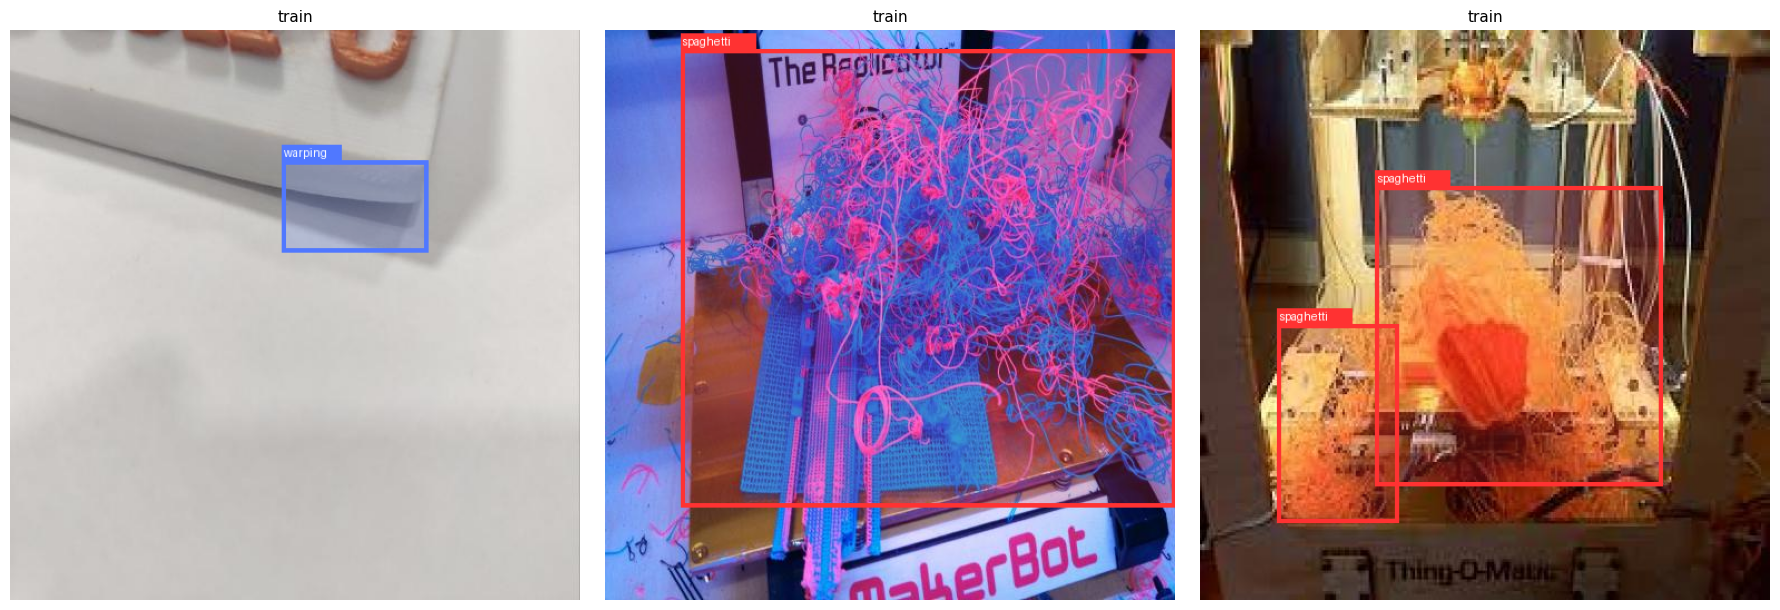

In [4]:
## Display some images
from img_display import show_samples

show_samples("3d-print-failure-detection-1/train", n=3)


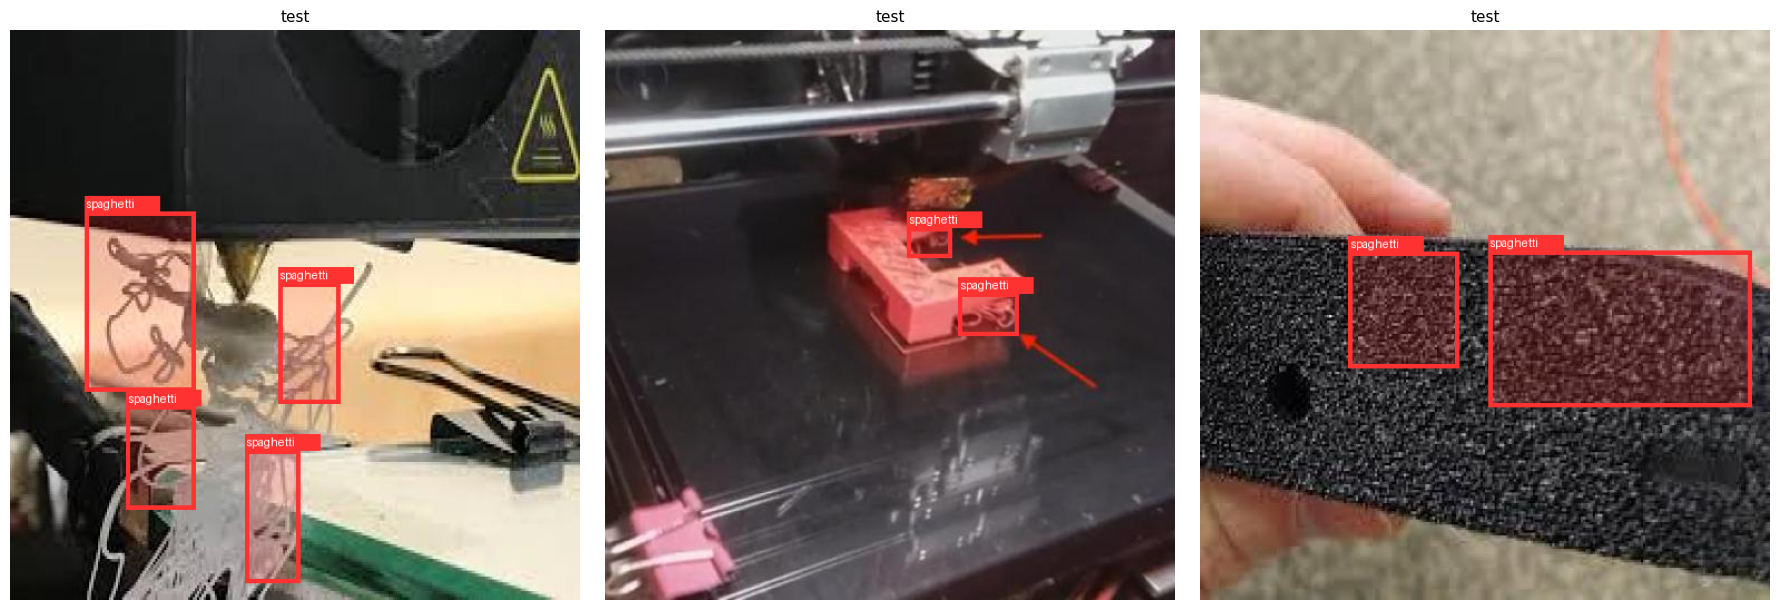

In [5]:
show_samples("3d-print-failure-detection-1/test", n=3)

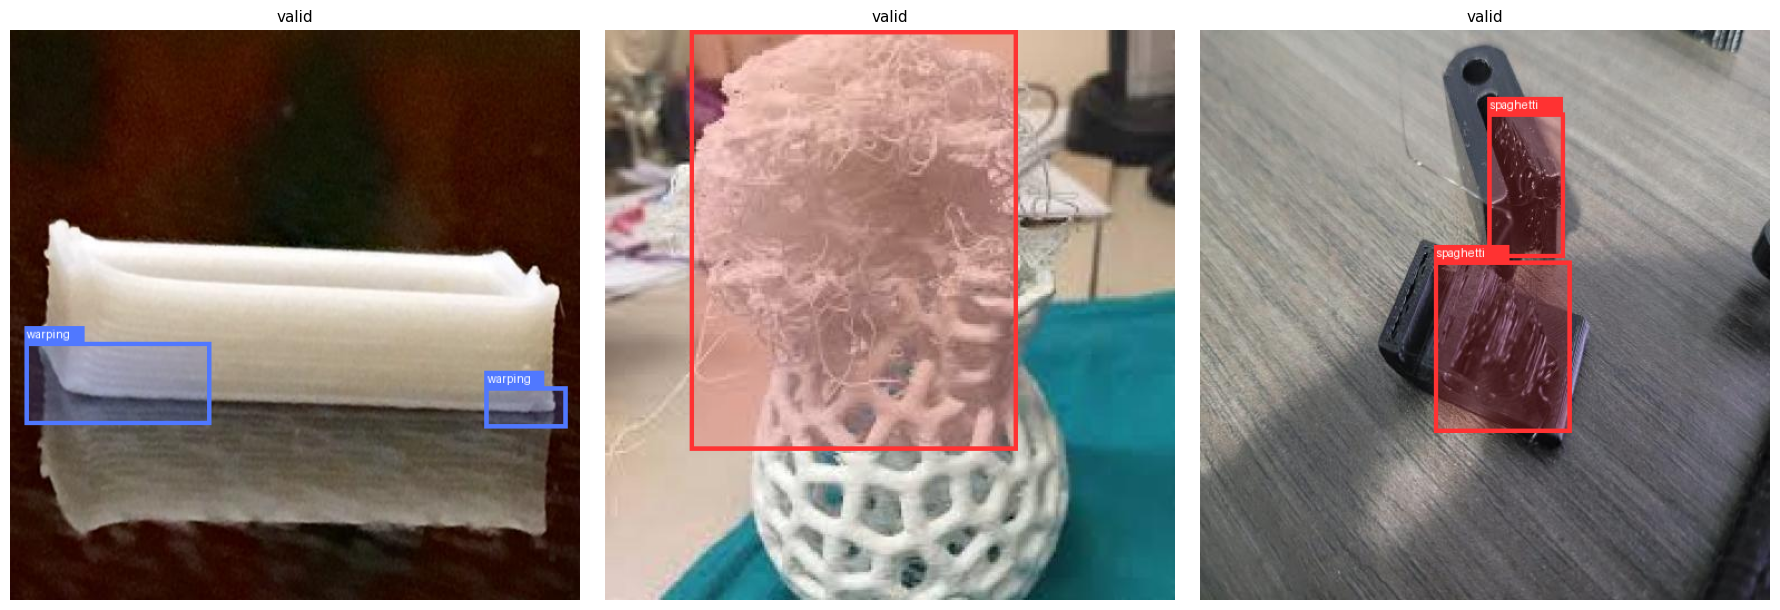

In [6]:
show_samples("3d-print-failure-detection-1/valid", n=3)

## 3. Train YOLOv8 Model

We start with **YOLOv8n** (nano) — smallest and fastest variant.
Good enough for our use case (detecting large failures at low FPS).

Scale up to `yolov8s` or `yolov8m` if accuracy needs improvement.

In [14]:
from ultralytics import YOLO

# Load pretrained YOLOv8 nano model
model = YOLO("yolov8n.pt")

# Train on our dataset
results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,            # Lower to 8 if you get OOM errors
    name="print_failure_detector",
    patience=10,         # Early stopping
    save=True,
    plots=True,
)

Ultralytics 8.4.37  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=3d-print-failure-detection-1\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=print_failure_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [15]:
from ultralytics import YOLO

# Load pretrained YOLOv8 medium model
model = YOLO("yolov8m.pt")

# Train on our dataset
results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,            # Lower to 8 if you get OOM errors
    name="print_failure_detector_medium",
    patience=10,         # Early stopping
    save=True,
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=3d-print-failure-detection-1\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, mu

## 4. Evaluate the Model

In [8]:
from ultralytics import YOLO

# Load the best weights
best_model = YOLO("runs/detect/print_failure_detector/weights/best.pt")

# Run validation
metrics = best_model.val()

print(f"\nmAP@0.5:      {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")

Ultralytics 8.4.37  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 63.340.5 MB/s, size: 29.6 KB)
val: Scanning C:\Users\User\Desktop\Me\3dPrint\src\3d-print-failure-detection-1\valid\labels.cache... 1524 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1524/1524 376.0Mit/s 0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 353, len(boxes) = 3420. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 96/96 8.4it/s 11.5s0.1s
                   all       1524       3420      0.398      0.265       0.23       0.11
             spaghetti        635       1354      0.455      0.428    

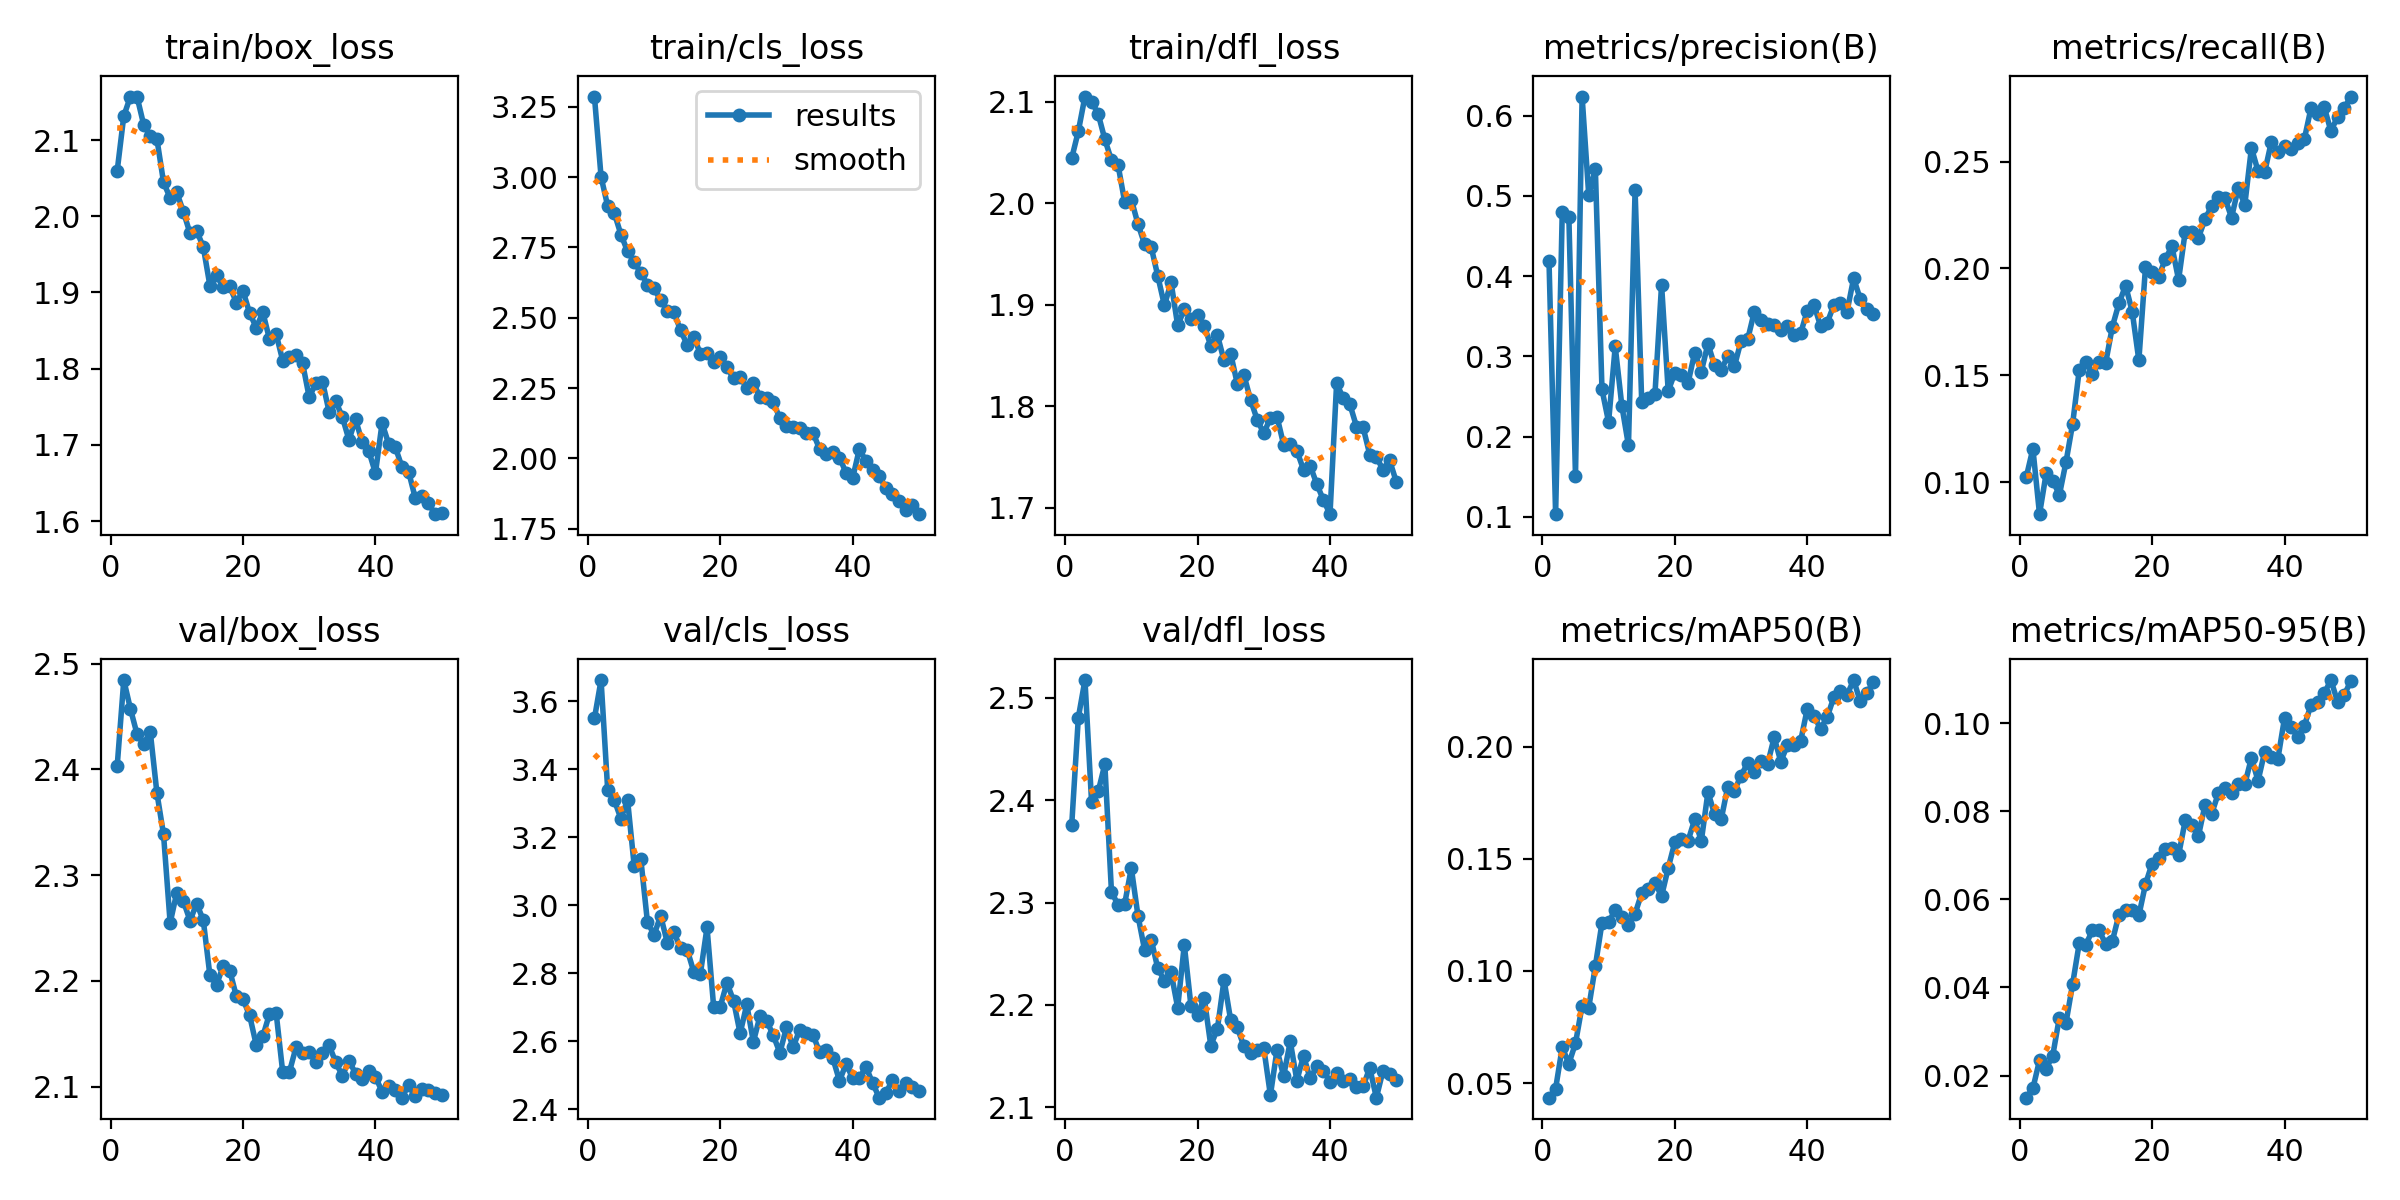

In [9]:
# Display training results
from IPython.display import Image, display

# Training curves
results_img = "runs/detect/print_failure_detector/results.png"
if os.path.exists(results_img):
    display(Image(filename=results_img, width=800))
else:
    print(f"Results image not found at {results_img}")

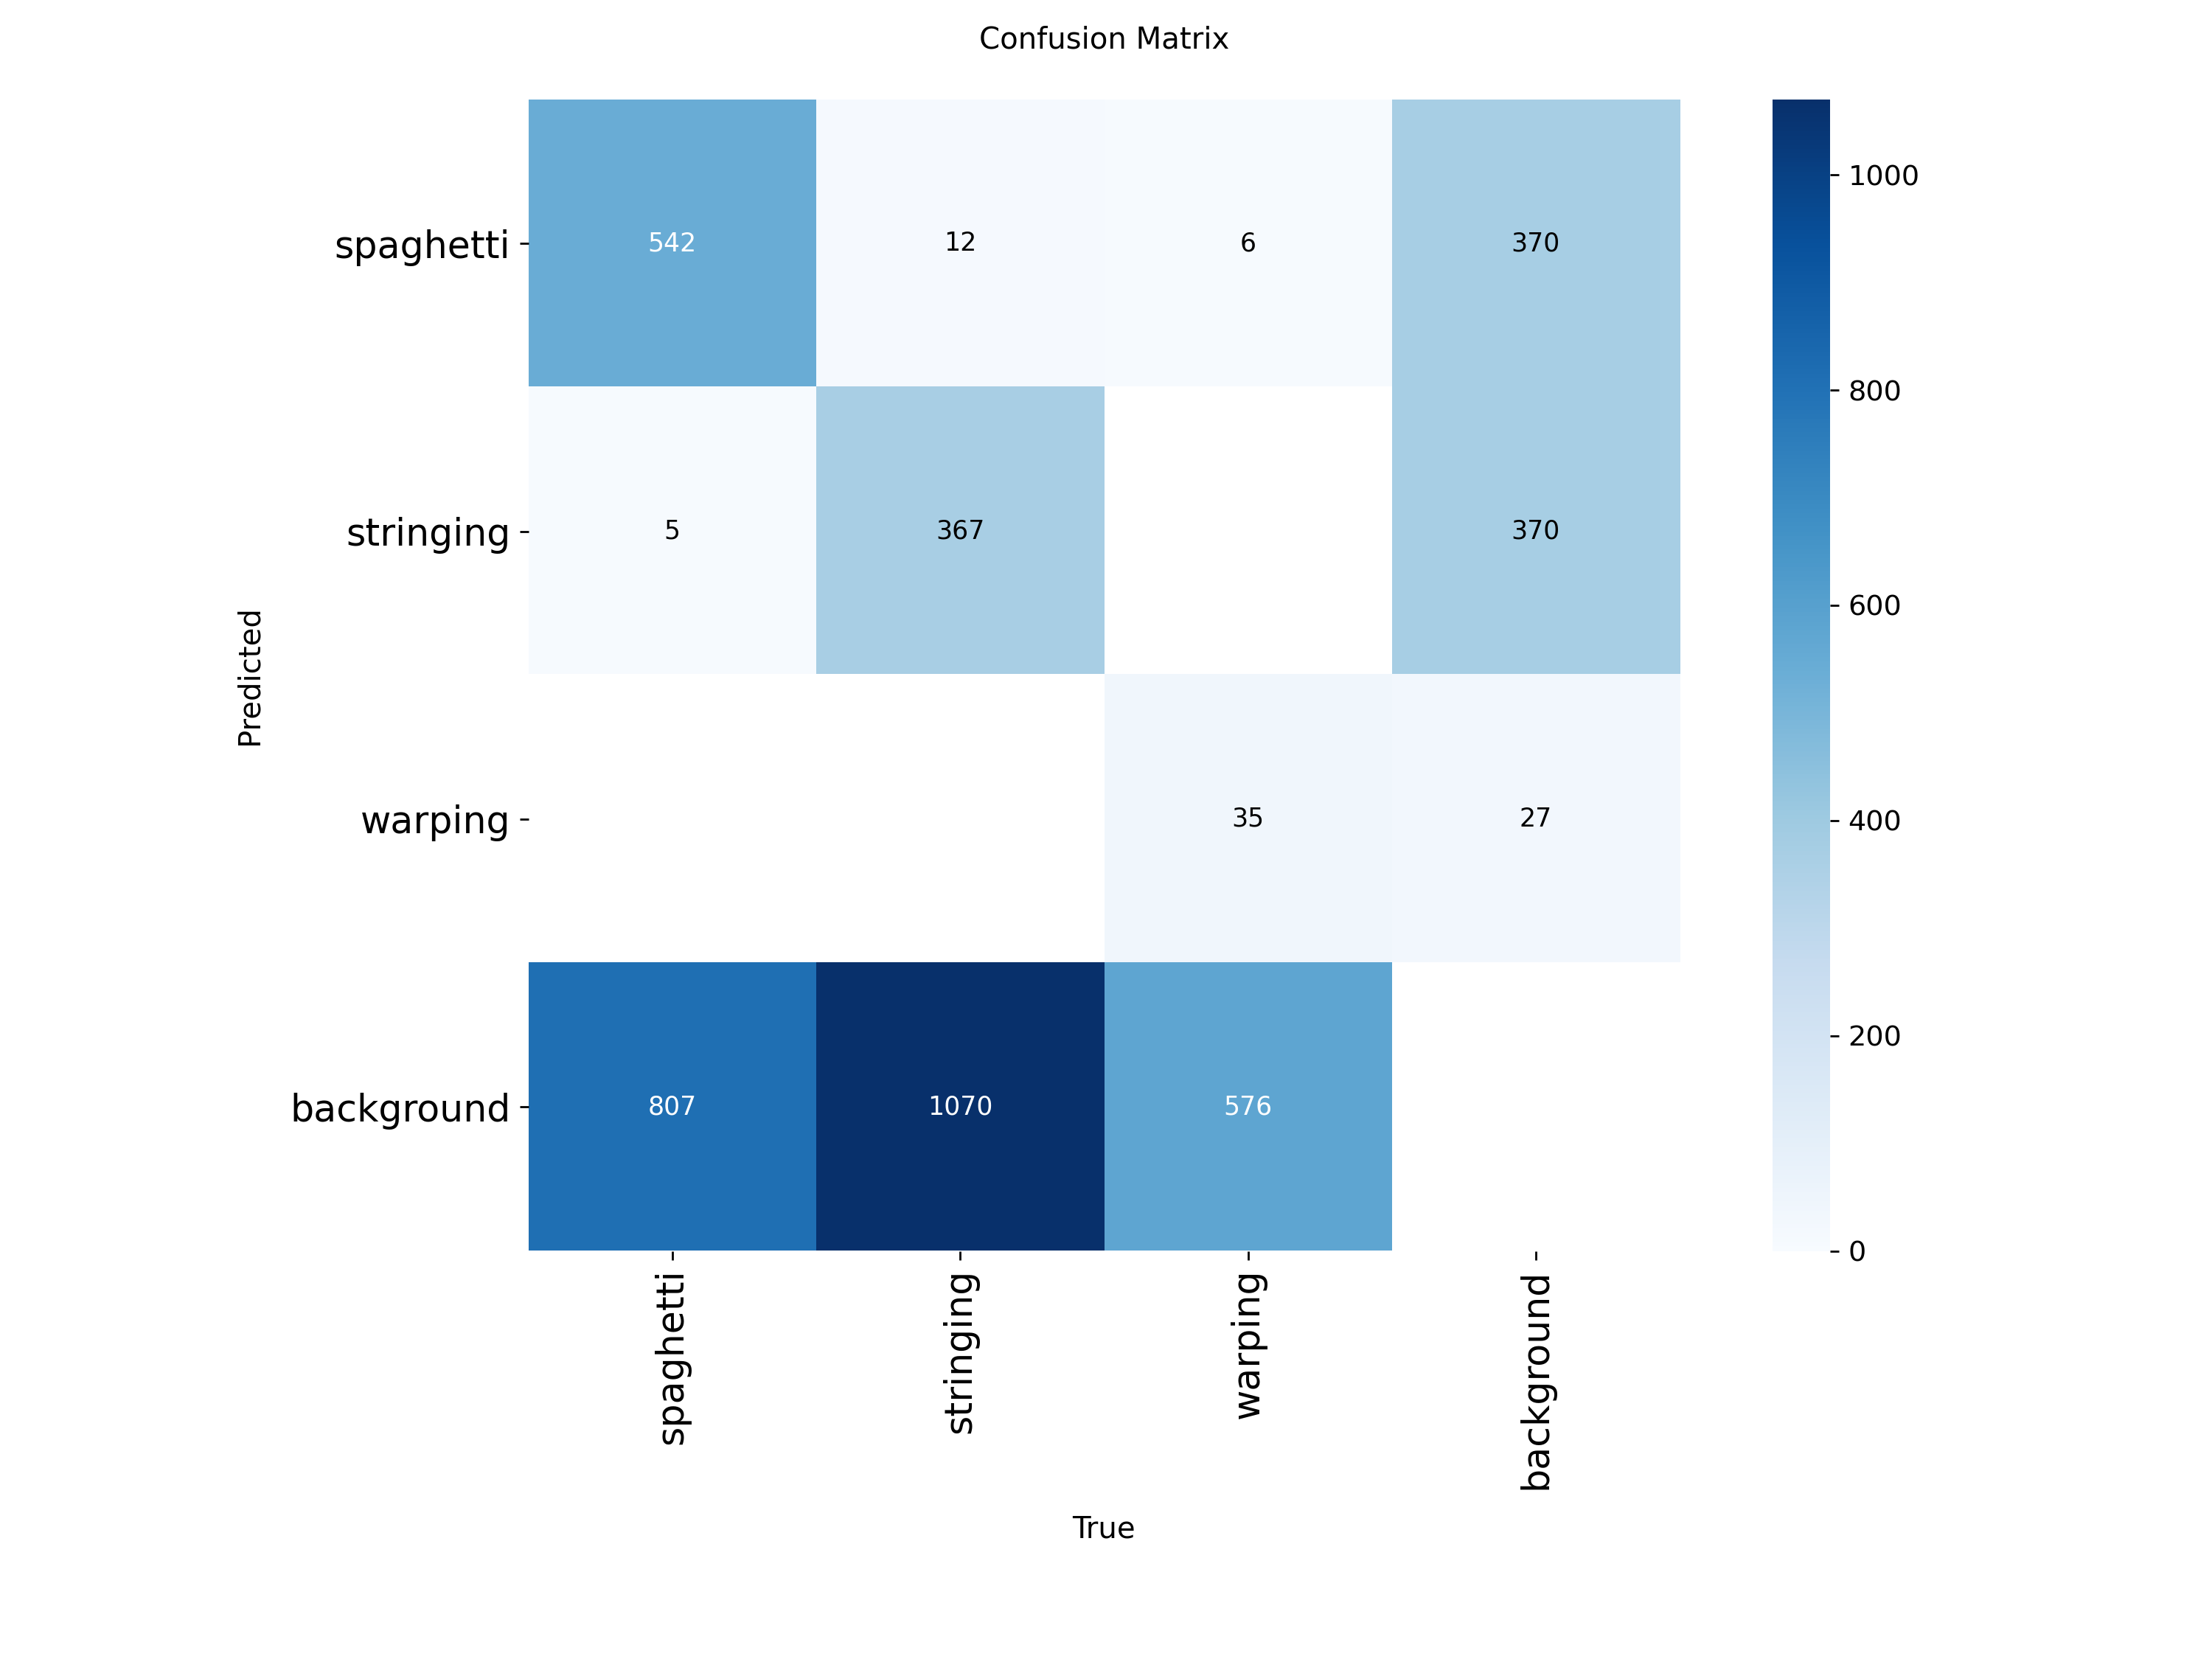

In [10]:
# Confusion matrix
cm_img = "runs/detect/print_failure_detector/confusion_matrix.png"
if os.path.exists(cm_img):
    display(Image(filename=cm_img, width=600))
else:
    print(f"Confusion matrix not found at {cm_img}")

## 5. Test on Sample Images

In [12]:
import glob

# Pick a few test images
test_images = glob.glob(os.path.join(dataset_location, "test", "images", "*"))[:4]

if test_images:
    results = best_model(test_images)
    for i, result in enumerate(results):
        # Save annotated image
        result.save(filename=f"test_result_{i}.jpg")
        print(f"Image {i}: {len(result.boxes)} detections")
        for box in result.boxes:
            cls_name = best_model.names[int(box.cls[0])]
            conf = float(box.conf[0])
            print(f"  - {cls_name}: {conf:.2f}")
else:
    print("No test images found")


0: 640x640 1 spaghetti, 62.2ms
1: 640x640 1 stringing, 62.2ms
2: 640x640 1 spaghetti, 62.2ms
3: 640x640 1 spaghetti, 62.2ms
Speed: 7.0ms preprocess, 62.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Image 0: 1 detections
  - spaghetti: 0.60
Image 1: 1 detections
  - stringing: 0.42
Image 2: 1 detections
  - spaghetti: 0.72
Image 3: 1 detections
  - spaghetti: 0.55


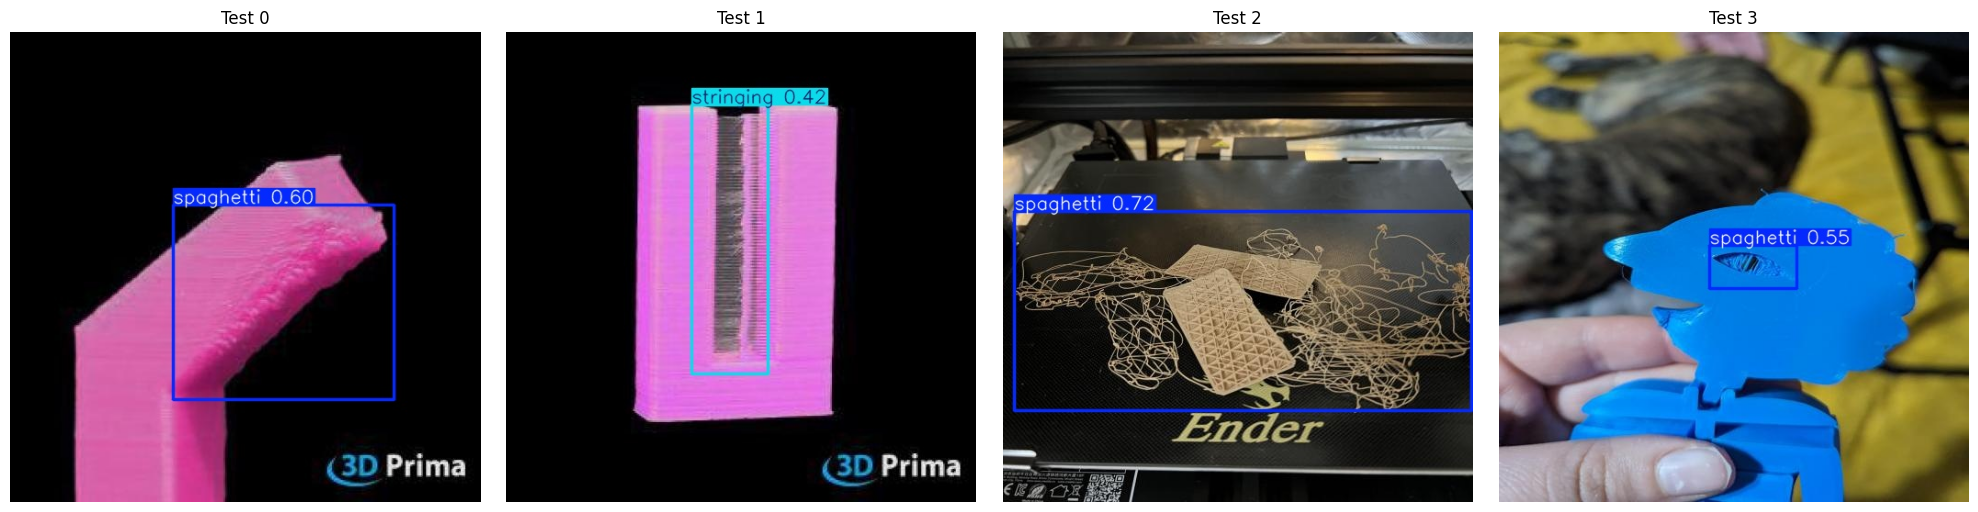

In [14]:
# Display test results (1x4 grid)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    img_path = f"test_result_{i}.jpg"
    if i < len(test_images) and os.path.exists(img_path):
        axes[i].imshow(mpimg.imread(img_path))
        axes[i].set_title(f"Test {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()


## ⚠️ Something is Wrong
Let's analyse why wrong results. mAP50 not increasing beyond 20%.

✅ Checklists:
 - `path in `data.yaml` with respect to project root
 - Labels exist for all?
 - Dataset imbalance
 - YOLO label format + Normalised?

### 1. Verify `data.yaml` file resolve correctly

In [18]:
import yaml, os, glob

with open(os.path.join(dataset_location, "data.yaml")) as f:
    cfg = yaml.safe_load(f)

for split in ["train", "val", "test"]:
    img_dir = os.path.normpath(os.path.join(dataset_location, cfg[split]))
    imgs = glob.glob(os.path.join(img_dir, "*.*"))
    print(f"{split}: {len(imgs)} images  →  {img_dir}")
    assert len(imgs) > 0, f"⚠️ NO IMAGES FOUND for {split}!"


train: 0 images  →  train\images


AssertionError: ⚠️ NO IMAGES FOUND for train!

### 2. 🐞Debug: print what `data.yaml` says vs what actually exists


In [19]:
with open(os.path.join(dataset_location, "data.yaml")) as f:
    cfg = yaml.safe_load(f)

print(f"CWD:              {os.getcwd()}")
print(f"dataset_location: {dataset_location}")
print(f"data.yaml paths:")
for split in ["train", "val", "test"]:
    raw = cfg[split]
    resolved = os.path.normpath(os.path.join(dataset_location, raw))
    exists = os.path.isdir(resolved)
    print(f"  {split}: '{raw}'  →  {resolved}  →  exists={exists}")

# Also show what folders DO exist in the dataset
print(f"\nActual contents of {dataset_location}:")
for item in os.listdir(dataset_location):
    full = os.path.join(dataset_location, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  📁 {item}/ ({count} items)")
    else:
        print(f"  📄 {item}")


CWD:              c:\Users\User\Desktop\Me\3dPrint\src
dataset_location: 3d-print-failure-detection-1
data.yaml paths:
  train: '../train/images'  →  train\images  →  exists=False
  val: '../valid/images'  →  valid\images  →  exists=False
  test: '../test/images'  →  test\images  →  exists=False

Actual contents of 3d-print-failure-detection-1:
  📄 data.yaml
  📄 README.dataset.txt
  📄 README.roboflow.txt
  📁 test/ (2 items)
  📁 train/ (3 items)
  📁 valid/ (3 items)


I see, wrong relative path of Train Test Valid samples in `config.yaml` file. Corrected now.

In [20]:
with open(os.path.join(dataset_location, "data.yaml")) as f:
    cfg = yaml.safe_load(f)

print(f"CWD:              {os.getcwd()}")
print(f"dataset_location: {dataset_location}")
print(f"data.yaml paths:")
for split in ["train", "val", "test"]:
    raw = cfg[split]
    resolved = os.path.normpath(os.path.join(dataset_location, raw))
    exists = os.path.isdir(resolved)
    print(f"  {split}: '{raw}'  →  {resolved}  →  exists={exists}")

# Also show what folders DO exist in the dataset
print(f"\nActual contents of {dataset_location}:")
for item in os.listdir(dataset_location):
    full = os.path.join(dataset_location, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  📁 {item}/ ({count} items)")
    else:
        print(f"  📄 {item}")


CWD:              c:\Users\User\Desktop\Me\3dPrint\src
dataset_location: 3d-print-failure-detection-1
data.yaml paths:
  train: 'train/images'  →  3d-print-failure-detection-1\train\images  →  exists=True
  val: 'valid/images'  →  3d-print-failure-detection-1\valid\images  →  exists=True
  test: 'test/images'  →  3d-print-failure-detection-1\test\images  →  exists=True

Actual contents of 3d-print-failure-detection-1:
  📄 data.yaml
  📄 README.dataset.txt
  📄 README.roboflow.txt
  📁 test/ (2 items)
  📁 train/ (3 items)
  📁 valid/ (3 items)


### 3. Check Labels Exists and are not Empty

In [22]:
# Do label files actually exist alongside images?
train_img_dir = os.path.normpath(os.path.join(dataset_location, cfg["train"]))
train_lbl_dir = train_img_dir.replace("images", "labels")

imgs = glob.glob(os.path.join(train_img_dir, "*.*"))
empty, missing = 0, 0
for img in imgs:
    lbl = os.path.join(train_lbl_dir, os.path.splitext(os.path.basename(img))[0] + ".txt")
    if not os.path.exists(lbl):
        missing += 1
    elif os.path.getsize(lbl) == 0:
        empty += 1

print(f"Total images: {len(imgs)}")
print(f"Missing labels: {missing}")
print(f"Empty labels (background): {empty}")
print(f"Labeled images: {len(imgs) - missing - empty}")


Total images: 2696
Missing labels: 0
Empty labels (background): 28
Labeled images: 2668


### 4. Validate label format ( Must be Normalized)

In [25]:
import random

# Pick a random label and inspect
lbls = glob.glob(os.path.join(train_lbl_dir, "*.txt"))
sample = random.choice([l for l in lbls if os.path.getsize(l) > 0])
print(f"Sample: {sample}\n")
with open(sample) as f:
    for line in f:
        parts = line.strip().split()
        print(f"  class={parts[0]}  cx={parts[1]}  cy={parts[2]}  w={parts[3]}  h={parts[4]}")
        # ALL values after class should be between 0.0 and 1.0
        for v in parts[1:]:
            assert 0.0 <= float(v) <= 1.0, f"⚠️ VALUE {v} OUT OF RANGE — labels may be pixel coords, not normalized!"
print("\n✅ Format looks correct")


Sample: 3d-print-failure-detection-1\train\labels\IMG_0275_jpg.rf.8cfdd03d1b9e4f63bc43ae58e98caf88.txt

  class=1  cx=0.396484375  cy=0.5048828125  w=0.541015625  h=0.5732421875

✅ Format looks correct


### 5. Check Class Distribution (Imbalance?)

In [26]:
from collections import Counter

class_counts = Counter()
for lbl in glob.glob(os.path.join(train_lbl_dir, "*.txt")):
    with open(lbl) as f:
        for line in f:
            cls = int(line.strip().split()[0])
            class_counts[cls] += 1

print("Class distribution:")
for cls_id, count in sorted(class_counts.items()):
    print(f"  {cfg['names'][cls_id]:>12s} (class {cls_id}): {count} instances")


Class distribution:
     spaghetti (class 0): 4117 instances
     stringing (class 1): 1404 instances
       warping (class 2): 380 instances


Huge imbalance observed. 

Measures:
 - cosine LR schedule (gentler decay)
 - augment = True (mosaic + mixup)


## Retrain Now

In [4]:
from ultralytics import YOLO

# Load pretrained YOLOv26 nano model
model = YOLO("yolo26n.pt")

# Train on our dataset
results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=8,            # Lower to 8 if you get OOM errors
    name="print_failure_detector_v26_nano",
    cos_lr=True,         # cosine LR schedule — gentler decay
    augment=True, 
    patience=10,         # Early stopping
    save=True,
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=3d-print-failure-detection-1\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi

In [ ]:
model = YOLO("yolo26s.pt")  # small instead of nano (more capacity)
results = model.train(
    data=data_yaml_path,
    epochs=150,          # wasn't converged at 50 hence
    imgsz=640,
    batch=8,
    device=0,
    name="print_failure_detector_v26_small",
    patience=30,         # more patience before early stopping
    cos_lr=True,
    # remove augment=True — YOLO26 doesn't support it anyway
)


New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=3d-print-failure-detection-1\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_

In [5]:
%ls

 Volume in drive C has no label.
 Volume Serial Number is 542C-8606

 Directory of c:\Users\User\Desktop\Me\3dPrint\src

18-04-2026  00:42    <DIR>          .
02-03-2026  08:03    <DIR>          ..
01-03-2026  21:24               320 .gitignore
16-04-2026  08:02    <DIR>          .ipynb_checkpoints
16-04-2026  08:47    <DIR>          __pycache__
16-04-2026  08:14    <DIR>          3d-print-failure-detection-1
16-04-2026  08:41             1,240 analyze_labels.py
01-03-2026  21:24             2,284 config.yaml
16-04-2026  08:46             3,431 img_display.py
01-03-2026  21:24            10,131 print_monitor.py
01-03-2026  21:24             2,694 README.md
01-03-2026  21:24               107 requirements.txt
16-04-2026  08:54    <DIR>          runs
17-04-2026  21:31            29,213 test_result_0.jpg
17-04-2026  21:31            30,697 test_result_1.jpg
17-04-2026  21:31            93,633 test_result_2.jpg
17-04-2026  21:31            49,828 test_result_3.jpg
18-04-2026  10:03        

exists: True, files: 2696
train_img_dir: 3d-print-failure-detection-1\train\images
exists: True
files: 2696


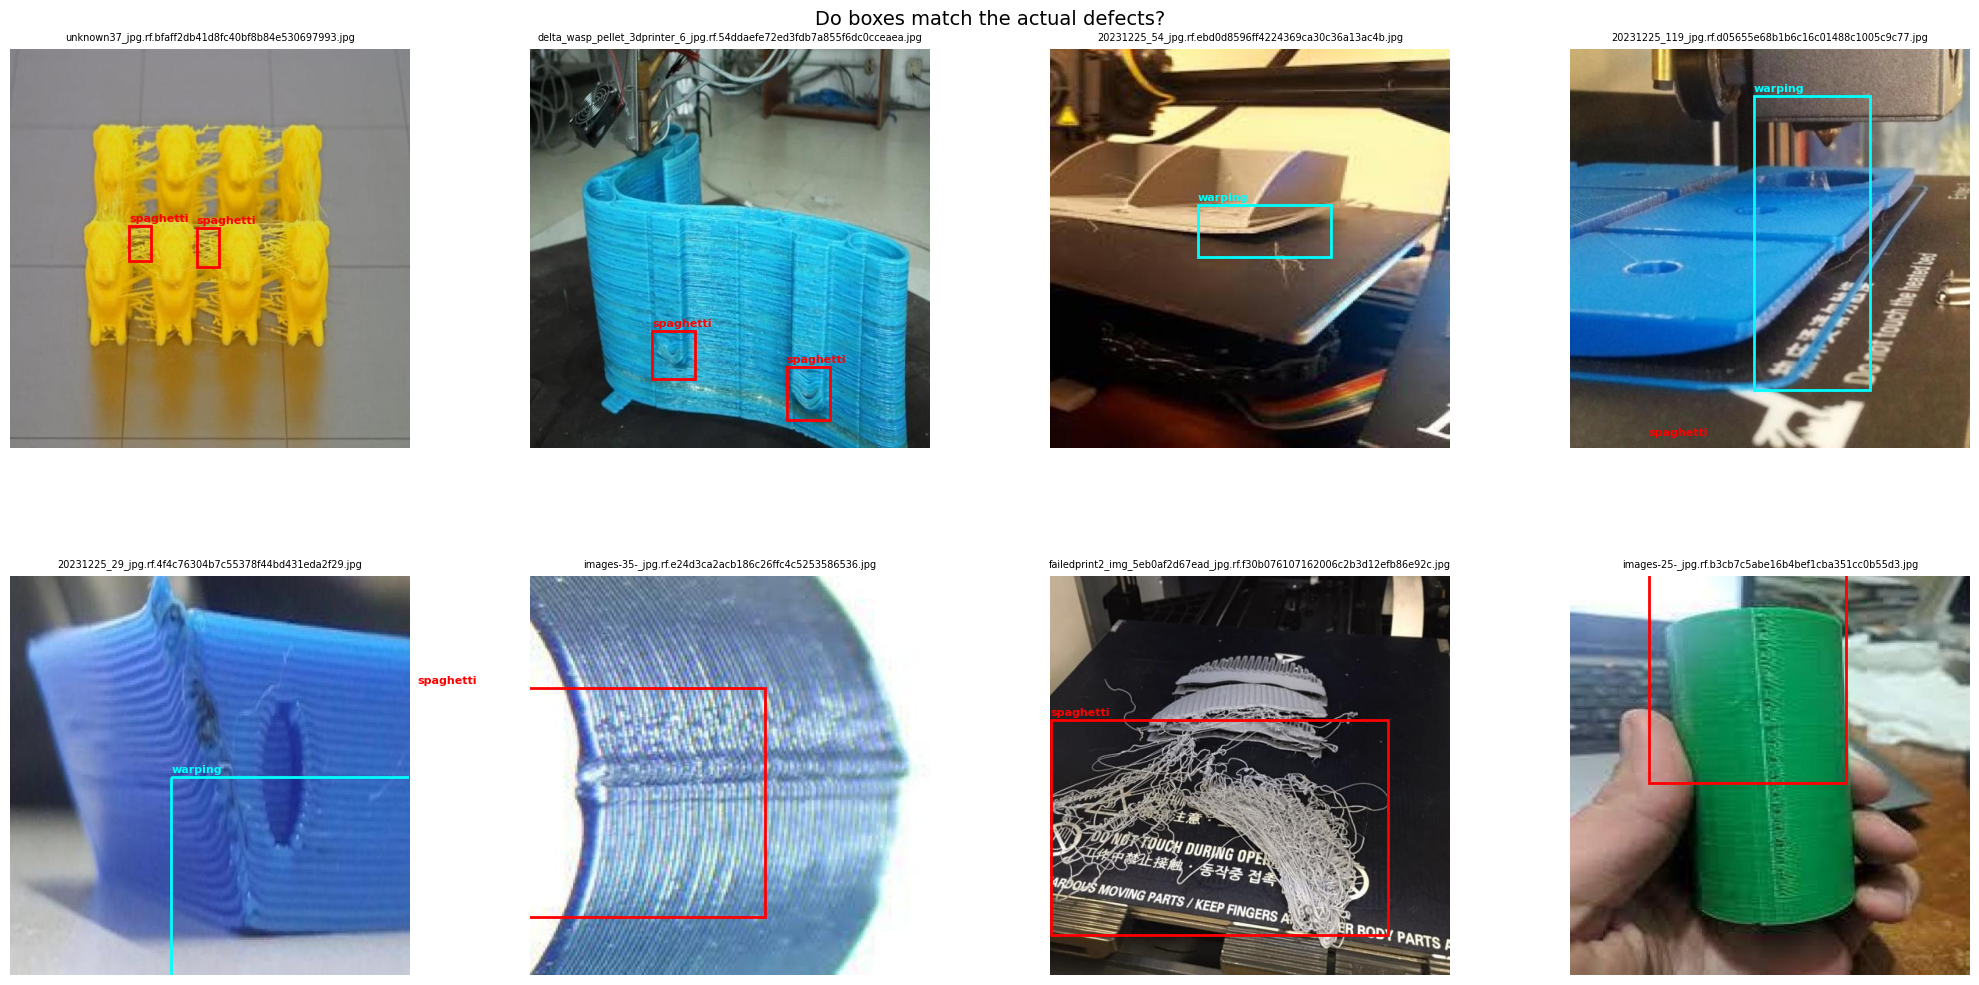

In [10]:
import cv2, random, glob, yaml, os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

dataset_location = "3d-print-failure-detection-1"

with open(os.path.join(dataset_location, "data.yaml")) as f:
    cfg = yaml.safe_load(f)

train_img_dir = os.path.join("3d-print-failure-detection-1", "train", "images")
train_lbl_dir = os.path.join("3d-print-failure-detection-1", "train", "labels")
print(f"exists: {os.path.isdir(train_img_dir)}, files: {len(glob.glob(os.path.join(train_img_dir, '*.*')))}")


print(f"train_img_dir: {train_img_dir}")
print(f"exists: {os.path.isdir(train_img_dir)}")
print(f"files: {len(glob.glob(os.path.join(train_img_dir, '*.*')))}")


fig, axes = plt.subplots(2, 4, figsize=(20, 10))
samples = random.sample(glob.glob(os.path.join(train_img_dir, "*.*")), 8)
colors = ["red", "lime", "cyan"]

for ax, img_path in zip(axes.flat, samples):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)
    
    lbl_path = os.path.join(train_lbl_dir, 
                os.path.splitext(os.path.basename(img_path))[0] + ".txt")
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                cls = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                rect = patches.Rectangle((x1, y1), bw*w, bh*h, linewidth=2,
                    edgecolor=colors[cls], facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1-5, cfg["names"][cls], 
                    color=colors[cls], fontsize=8, weight="bold")
    ax.set_title(os.path.basename(img_path), fontsize=7)
    ax.axis("off")

plt.suptitle("Do boxes match the actual defects?", fontsize=14)
plt.tight_layout()
plt.show()


## 6. Export Model

The trained weights are saved at:
```
runs/detect/print_failure_detector/weights/best.pt
```

Download this file and place it in your `PrintFailureDetection/` directory to use with `print_monitor.py`.

In [ ]:
# Export to ONNX (optional, for deployment on edge devices)
# best_model.export(format="onnx")

print("Best weights location:")
weights_path = "runs/detect/print_failure_detector/weights/best.pt"
if os.path.exists(weights_path):
    size_mb = os.path.getsize(weights_path) / (1024 * 1024)
    print(f"  {weights_path} ({size_mb:.1f} MB)")
else:
    print(f"  Weights not found at {weights_path}")

print("\nTraining complete! Download best.pt and run:")
print("  python print_monitor.py")

---

## Quick Reference

| Metric | What it means |
|--------|---------------|
| **mAP@0.5** | Accuracy at 50% IoU threshold (main metric) |
| **mAP@0.5:0.95** | Average accuracy across IoU thresholds |
| **Recall** | What fraction of real failures are detected |
| **Precision** | What fraction of detections are correct |

**Target:** mAP@0.5 > 0.7 for usable detection. Prioritize **high recall for spaghetti** (better to false alarm than miss a real failure).